# Polynomial-cost orbital optimization of cluster number quasisymetries

In [19]:
import numpy as np

# Molecule input parameters
molecule = 'h2o'              # supports: h2, h2o, n2, lih, h4_linear, h4_square
bond_length = 1.            # Angstrom
basis = '6-31g'              # 'sto3g', '6-31g', ...

# Clustering parameters
use_custom_cluster_matrix = True # True: set your cluster matrix below, #TODO False: automatic cluster_matrix optimization, set num_clusters below
if use_custom_cluster_matrix: # num_clusters x norb binary matrix with custom clusters. Clusters should not overlap nor use all orbitals.
    cluster_matrix = np.array([
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
    ])

# h2o in 6-31g basis:
    # cluster_matrix = np.array([
    #    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    #    [0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    #    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]
    #])
else:
    num_clusters = 3 # specify number of clusters

# DMRG parameters
bond_dim = 100 # 500
n_sweeps = 20 # 20

# High-level input parameters
initial_basis = 'MOs' # 'MOs': HF molecular orbitals, 'NatOs': natural orbitals, #TODO 'LocOs': orbitals localized on nuclei via...
num_transfers = 2 # maximal number of inter-cluster electron transfers starting from fundamental sector
type_cost_function = 'variance' # 'variance' or 'eval_eq'
maxiter = 100 # iterations for the optimization

In [20]:
# Verify input validity

if use_custom_cluster_matrix:
    # Calculate the sum of each column (one column per orbital)
    column_sums = np.sum(cluster_matrix, axis=0)
    if not np.all(np.isin(column_sums, [0, 1])):
        invalid_columns = np.where((column_sums != 0) & (column_sums != 1))[0]
        raise ValueError(f"Error: Orbitals {invalid_columns} should appear in at most one cluster.")
    if any([all(bit == 0 for bit in cluster) for cluster in cluster_matrix]):
        raise ValueError(f"Error: There is one or more empty clusters.")
    if np.all(column_sums == 1):
        raise ValueError(f"Error: The clusters cover all orbitals. Remove one cluster to avoid redundancy.")
    num_clusters = len(cluster_matrix)

In [21]:
# ============================================================================
# SECTION 1: Run DMRG using MOs as sites to get ground state approximation as mps
# ============================================================================
import sys
sys.path.insert(0, '..') 
import src.cluster_number_operators as cluster_nums
import pyscf
from chemistry import get_geometry_and_description
from src.dmrg_solver import Block2DMRGSolver, DMRGConfig, solve_or_load_ground_state
import tempfile
from math import comb

# --- Step 1.1: Build molecule and run HF ---
geometry, _ = get_geometry_and_description(molecule, bond_length)
mol = pyscf.M(atom=geometry, basis=basis)
mf = pyscf.scf.RHF(mol)
mf.kernel()

norb, nelec = mol.nao, mol.nelec
assert norb == cluster_matrix.shape[1], f"Number of columns of cluster_matrix = {cluster_matrix.shape[1]} does not match number of orbitals = {norb}"
print(f"Number of orbitals: {norb}")
print(f"Number of elecs: {nelec}")
dim = comb(norb, nelec[0]) * comb(norb, nelec[1])
print(f"Hilbert space dimension: {dim}")
h1e = mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff
g2e = pyscf.ao2mo.full(mol, mf.mo_coeff) # compressed
# recall: chemist notation (pq|rs) = int d1 d2 \bar phi_p(1) phi_q(1) 1/r_12 \bar phi_r(2) phi_s(2) = <p, r| W |q, s>
ecore = mol.energy_nuc()

# --- Step 1.2: Run DMRG ---
store_dir = tempfile.mkdtemp(prefix='dmrg_')
solver = Block2DMRGSolver( # handles nelec as integer or pair
    h1e=h1e, g2e=g2e, ecore=ecore,
    n_elec=nelec, spin=mol.spin,
    store_dir=store_dir, n_threads=1
)
result = solve_or_load_ground_state(
    solver,
    config=DMRGConfig(max_bond_dim=bond_dim, n_sweeps=n_sweeps),
    reuse=False
)
dmrg_energy = result.energy
print(f"DMRG Energy: {dmrg_energy} Ha")

converged SCF energy = -75.9801579220088
Number of orbitals: 13
Number of elecs: (5, 5)
Hilbert space dimension: 1656369
DMRG Energy: -76.11869253057966 Ha


In [23]:
# ============================================================================
# SECTION 2: Get 1- and 2-RDMs from the mps
# ============================================================================

# --- Step 2.1: Extract RDMs directly from MPS ---

# get mps
mps_tag = result.mps_tag
available_tags = solver.stored_tags()
if mps_tag not in available_tags:
    raise RuntimeError(
        f"Expected MPS tag '{mps_tag}' not found in store "
        f"{solver.store_dir}; available tags: {available_tags}"
    )
mps = solver.get_mps(tag=mps_tag)

# get rdms
rdm1_a, rdm1_b = solver.driver.get_1pdm(mps)
rdm2_aa, rdm2_ab, rdm2_bb = solver.driver.get_2pdm(mps)
# Formulas:
#
# rdm1_sigma[p, q] = <mps|a^dag_{p sigma}a_{q sigma}|mps>
#
# rdm2_aa[p, q, r, s] = <mps| a^dag_{p,alpha} a^dag_{q,alpha} a_{r,alpha} a_{s,alpha} |mps>   (alpha-alpha)
# rdm2_ab[p, q, r, s] = <mps| a^dag_{p,alpha} a^dag_{q,beta}  a_{r,beta}  a_{s,alpha} |mps>   (alpha-beta)
# rdm2_bb[p, q, r, s] = <mps| a^dag_{p,beta}  a^dag_{q,beta}  a_{r,beta}  a_{s,beta}  |mps>   (beta-beta)
#
# if needed, rdm2_ba[p, q, r, s] = <mps| a^dag_{p,beta} a^dag_{q,alpha}  a_{r,alpha}  a_{s,beta} |mps> (beta-alpha)
# is for any state given by:
# rdm2_ba[p, q, r, s] = rdm2_ab[q, p, s, r]

print(f"rdm1_a, type: {type(rdm1_a)}, shape: {np.shape(rdm1_a)}, trace: {np.trace(rdm1_a).round(8)}")
# print("rdm1_a:\n", rdm1_b.round(3))
print(f"Length of rdm2_aa: {len(rdm2_aa)}, shape of rdm2_aa: {np.shape(rdm2_aa)}")

rdm1_a, type: <class 'numpy.ndarray'>, shape: (13, 13), trace: 5.0
Length of rdm2_aa: 13, shape of rdm2_aa: (13, 13, 13, 13)


In [24]:
# ============================================================================
# SECTION 2: Get best clusters, described via a binary cluster_matrix
# (if custom_cluster_matrix = None). Should use adaptation of Praveen's beam search.
# Can also use a Fiedler-like preliminary ordering of the orbitals, before beam search.
# See Praveen's thesis -> 4.5 Indexing symmetries with Fiedler reordering) 
# Careful: correlations of two orbitals in two different clusters
# are not a problem (e.g. H2); you really want small cluster number fluctuations...
# Still, some cheap two-orbital information-based preprocessing can help.
# ============================================================================
if use_custom_cluster_matrix == False:
    #TODO
    cluster_matrix = []

In [25]:
# ============================================================================
# SECTION 3: Get the optimal orbital basis, starting from initial_basis.
# Optimization cost function type is given by type_cost_function.
# ============================================================================

from math import comb
import scipy.optimize
from src.cluster_number_operators import params_to_U_jax
import jax
import jax.numpy as jnp

D = rdm1_a + rdm1_b
Gamma = rdm2_aa + rdm2_bb + rdm2_ab + rdm2_ab.transpose(1, 0, 3, 2)

if initial_basis == 'NatOs':
    # get the unitary that diagonalizes D0: 
    spec, evecs = np.linalg.eigh(D)
    # rotate D and Gamma and endure consequences of indexing that was beneficial somewhere else
    U_nat = evecs.T
    U_nat_conj = np.conj(U_nat)
    D = U_nat_conj @ D @ U_nat.T
    Gamma = np.einsum('pi,qj,rk,sl,ijkl->pqrs', U_nat_conj, U_nat_conj, U_nat, U_nat, Gamma, optimize=True)
    # print(np.all(np.isclose(D, np.diag(spec)))) # True

if initial_basis == 'LocOs':
    #TODO
    D = []
    Gamma = []

# --- Step 3.1: Build cost function ---
# define loc_number_evaluator, a function that computes efficiently the 1- and 2-orbital number expectation values
# of the rotated state that are relevant for the given clusters. Single call cost is O(norb^5)
loc_number_evaluator = cluster_nums.build_loc_number_evaluator(D, Gamma, cluster_matrix=cluster_matrix)

if type_cost_function == 'variance':
    f = cluster_nums.number_variance_cost(D, Gamma, cluster_matrix, with_ghost=False)

if type_cost_function == 'eval_eq':
    # precompute the guessed eigenvalues
    clusters = cluster_nums.get_cluster_indices(cluster_matrix, norb, with_ghost=False) # number_eval_eq_cost attaches the ghost cluster number eigenvalue already; you do not need to precompute it
    evals = []
    for cluster in clusters:
        cluster_num_average = D[cluster, cluster].sum()
        evals.append(round(cluster_num_average))
    f = cluster_nums.number_eval_eq_cost(D, Gamma, cluster_matrix, evals)

# get with JAX function and gradient
f_val_and_grad = jax.jit(jax.value_and_grad(f))

# Wrap for SciPy (SciPy expects standard NumPy arrays and float64 returns)
def scipy_f(x):
    val, grad = f_val_and_grad(x)
    return float(val), jnp.asarray(grad, dtype=jnp.float64)

# Same, but no gradient
def scipy_f_nograd(x):
    val, grad = f_val_and_grad(x)
    return float(val)

# --- Step 3.2: Initial guess (identity rotation) ---
x0 = np.zeros(comb(norb, 2))
initial_cost = f(x0)
print(f"\nInitial cost (identity rotation): {initial_cost:.6e}")

# --- Step 3.3: Run optimization ---
"""
# track iterations
class IterationTracker:
    def __init__(self):
        self.iteration = 0

    def __call__(self, intermediate_result):
        self.iteration += 1
        # Extract cost (fun) and current parameters (x)
        cost = intermediate_result.fun
        print(f"Iteration {self.iteration:3d} | Cost: {cost:.6f}")

tracker = IterationTracker()
"""

print("\nRunning orbital optimization...")
result = scipy.optimize.minimize(
    fun=scipy_f,
    x0=x0,
    method='L-BFGS-B',
    jac=True,  # Tells SciPy that objective function returns (value, gradient)
#    callback=tracker,
    options={'maxiter': 100, 'disp': True}
)
optimized_cost = result.fun
print(f"Optimized cost: {optimized_cost:.6e}")
print(f"Cost change: {(- initial_cost + optimized_cost)/initial_cost * 100:.2f}%")

# --- Step 3.4: Extract optimized orbital rotation ---
x_opt = result.x
U_opt = params_to_U_jax(x_opt, norb)

# --- Step 3.5: Compare with randomly rotated orbitals ---
num_random_Us = 5
xs_random = [10 * np.random.rand(comb(norb, 2)) for _ in range(num_random_Us)]
random_costs = [f(x_random) for x_random in xs_random]
random_costs_perc = [int((- initial_cost + random_cost)/initial_cost * 100) for random_cost in random_costs]
print(f"\nFor reference, % cost change for some random unitaries: {', '.join(map(str, random_costs_perc))}%")


Initial cost (identity rotation): 2.025866e-01

Running orbital optimization...


/var/folders/r2/2ny_rjqj5w93mz1ll0gd2vbr0000gp/T/ipykernel_17900/4105119265.py:82: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = scipy.optimize.minimize(


Optimized cost: 4.543455e-02
Cost change: -77.57%

For reference, % cost change for some random unitaries: 1776, 1407, 1660, 1248, 1338%


In [ ]:
# ============================================================================
# SECTION 4: Get labels of dominant sector and sectors obtained from it by 
# moving up to num_transfers electrons
# ============================================================================

Number of symmetry sectors identified: 171

--> Chemical accuracy achieved at K_sector=35!


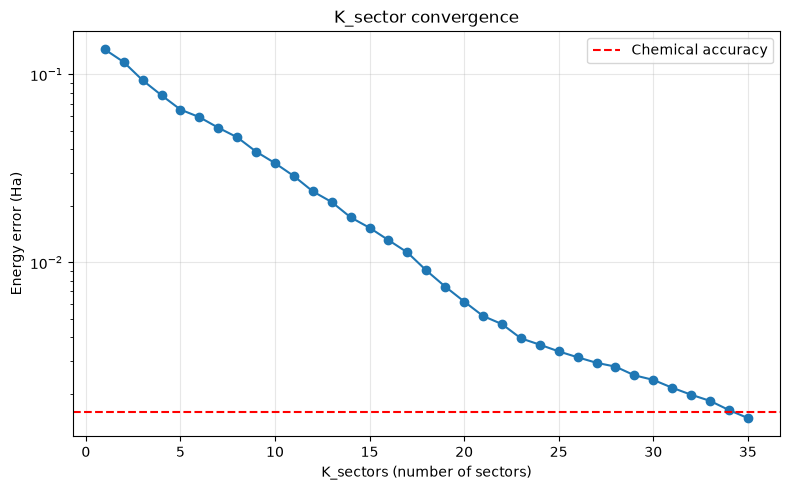


--> Chemical accuracy achieved at K_sector=17!


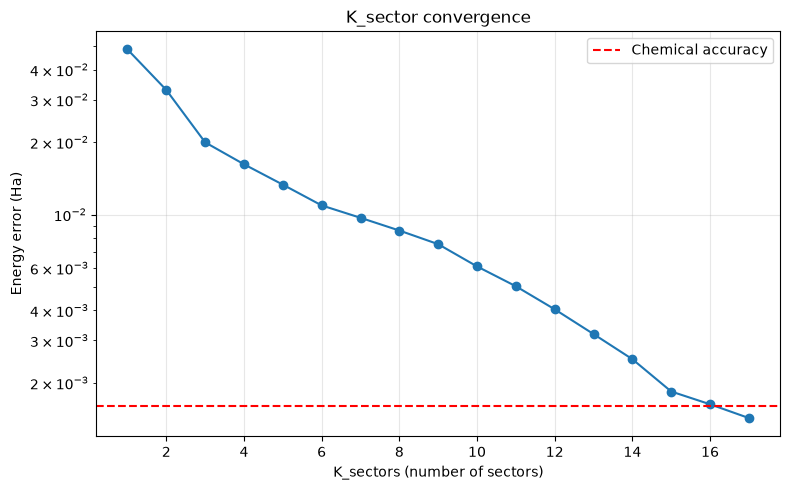

In [26]:
# ============================================================================
# SECTION 5: For small systems, evaluate quality of sector decomposition
# by plotting K_sectors -> ΔE, before and after orbital optimization
# ============================================================================
import ffsim
from src.cluster_number_operators import number_and_parity_symmetry_sectors
import matplotlib.pyplot as plt
from chemistry import CHEMICAL_PRECISION
import pyscf.ao2mo

# --- Step 5.1: Get full state vectors ---
# get full state
psi_0 = solver.to_ci_vector(ket=mps)

assert len(psi_0) == dim, f"Number of columns of cluster_matrix = {cluster_matrix.shape[1]} does not match number of orbitals = {norb}"

# rotate state and Hamiltonian with optimal unitary
psi_rotated = ffsim.apply_orbital_rotation(
    psi_0, np.array(U_opt), norb, nelec)

# --- Step 5.4: Get full hamiltonians --- 
# Restore compressed g2e to a 4D array of shape (norb, norb, norb, norb)
g2e_full = pyscf.ao2mo.restore(1, g2e, norb)

# Construct the ffsim Hamiltonian using chemist notation integrals
hamiltonian = ffsim.MolecularHamiltonian(
    one_body_tensor=h1e, 
    two_body_tensor=g2e_full, 
    constant=ecore
)

# Generate the linear operator acting on the (N_alpha, N_beta) subspace
h_linop_0 = ffsim.linear_operator(hamiltonian, norb, nelec)

# get rotated Hamiltonian
rotated_h = hamiltonian.rotated(U_opt)
h_linop_rotated = ffsim.linear_operator(rotated_h, norb, nelec)

# --- Step 5.3: Identify symmetry sectors by partitioning the computational/fock basis --- 
# Each configuration/bitstring/basis SD gets assigned to a sector based on
# the eigenvalues of the cluster numbers
sectors = number_and_parity_symmetry_sectors(cluster_matrix, [], norb, nelec)
print(f"Number of symmetry sectors identified: {len(sectors)}")

# --- Step 5.4: plot K_sectors -> energy ---

def projected_energy_sectors(K_sector, psi, h_linop, ordered_state_projections_in_sectors):
    """Compute energy using only the K_sector most important sectors"""
    # check definitions

    # Create compressed coefficient vector
    compressed_coeffs = np.zeros_like(psi, dtype='complex')
    for i in range(K_sector):
        sector_label, (projection, norm_squared, energy) = ordered_state_projections_in_sectors[i]
        compressed_coeffs += projection

    # Normalize
    compressed_coeffs /= np.linalg.norm(compressed_coeffs)

    # Compute energy
    e_proj = compressed_coeffs.T.conj() @ h_linop @ compressed_coeffs
    return e_proj.real

for psi, h_linop in [(psi_0, h_linop_0), (psi_rotated, h_linop_rotated)]:
    assert np.isclose(dmrg_energy, np.vdot(psi, h_linop @ psi), atol=1e-10)
    state_projections_in_sectors = {} # key = sector label (as in sectors), value = (projection of psi into sectors, norm squared)
    for sector_label, sector_indices in sectors.items():
        projection = np.zeros(psi.shape, dtype='complex')
        projection[sector_indices] = psi[sector_indices]
        norm_squared = np.linalg.norm(projection)**2
        energy = np.real(projection.T.conj() @ h_linop @ projection / norm_squared) if norm_squared > 0 else np.nan
        state_projections_in_sectors[sector_label] = (projection, norm_squared, energy)

    # order state_projections_in_sectors projections by norm_squared
    ordered_state_projections_in_sectors = sorted(state_projections_in_sectors.items(), key=lambda x: x[1][1], reverse=True)
    # print(f"\nState projections in sectors (ordered by norm squared):")
    #for sector_label, (projection, norm_squared, energy) in ordered_state_projections_in_sectors:
    #    print(f"Projection of psi into sector {sector_label}: norm squared = {norm_squared:.6f}, energy of projection = {energy:.6f}")
    print()

    # Convergence in the number of sector states retained
    K_sectors_values = []
    K_sectors_energies = []
    for K_sectors in range(1, len(ordered_state_projections_in_sectors) + 1):
        K_sectors_values.append(K_sectors)
        e_K = projected_energy_sectors(K_sectors, psi, h_linop, ordered_state_projections_in_sectors)
        K_sectors_energies.append(e_K)
        error = e_K - dmrg_energy
        #print(f"K_sector={K_sectors:2d}: E={e_K:.8f}, Error={error:.8f} Ha = {error*27.2114:.4f} eV")
        if error < CHEMICAL_PRECISION:
            print(f"--> Chemical accuracy achieved at K_sector={K_sectors}!")
            break

    # Plot energy error vs K_sector
    plt.figure(figsize=(8, 5))
    plt.plot(K_sectors_values, [e - dmrg_energy for e in K_sectors_energies], 'o-')
    plt.axhline(CHEMICAL_PRECISION, color='r', linestyle='--', label='Chemical accuracy')
    plt.xlabel('K_sectors (number of sectors)')
    plt.ylabel('Energy error (Ha)')
    plt.title('K_sector convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()



In [ ]:
print(f"Cost change: {(- initial_cost + optimized_cost)/initial_cost * 100:.2f}%")
print(f"Initial cost: {initial_cost}")
print(f"Optimized cost: {optimized_cost}")
print(f"dim {dim}")
print(f"psi first entries: {psi_0[:6]}")

Cost change: -32.77%
Initial cost: 0.3350576177884208
Optimized cost: 0.22526247609971736
dim 14400
psi first entries: [ 9.68603676e-01+0.j  7.91610600e-09+0.j  2.45903515e-08+0.j
 -4.95937997e-08+0.j  5.25901821e-07+0.j -6.05304573e-09+0.j]
